# Feature Engineering
The examples in this session are inspired by the course lectures from Summer 2025 taught by Dr. Marek Hatala
## What is Feature Engineering?

**Feature engineering** is the process of using domain knowledge to transform raw data into meaningful inputs (called *features*) for a machine learning model or statistical analysis.

Raw data on its own is rarely in a form that models can learn from directly. For example:
- A **timestamp** tells you when something happened — but your model cannot directly use `'2020-05-26 22:15:00'`. A more useful feature might be `days_before_deadline`.
- A **list of page visits** does not tell you much alone — but `total number of visits` or `time spent per assignment` are informative summaries.

In this lecture, we will practice feature engineering on a real dataset: **Canvas LMS log data** from an online programming course. Our goal is to build features that help explain why some students perform better on assignments than others.

---

### The three feature families we will explore today

| # | Feature family | Example | Intuition |
|---|---|---|---|
| 1 | **Count & time aggregates** | `totalCount`, `totalTime` | How much did the student engage overall? |
| 2 | **Temporal / day-based features** | `firstDay`, `nDays`, `nDaysFinalWeek` | *When* did the student work — did they cram or spread it out? |
| 3 | **Ratios** | `detailRatio` | What *proportion* of their time was spent on detail vs. overview pages? |

---

We continue from Week 4 where we computed `view_length` (capped at 30 minutes). Let's reload the data.

In [59]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

log = pd.read_csv('transformed_dataset.csv')
grades = pd.read_csv('grades_data.csv')

print(log.head(10))
print("*****")
print(grades.head(10))

   userID assignment                                                url  \
0  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
1  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
2  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
3  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
4  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-m...   
5  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
6  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
7  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
8  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
9  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   

                  start_time  view_length  
0  2026-05-20 16:19:42-07:00         22.0  
1  2026-05-20 16:20:49-07:00       1524.0  
2  2026-05-22 23:31:51-07:00         11.0 

---
## Feature Family 1 — Count & Time Aggregates

The simplest features we can compute are **totals per student per assignment**:
- `totalCount` — how many times did the student visit any page for this assignment?
- `totalTime` — how many seconds in total did the student spend on those pages?

These are called **aggregation features**: we are collapsing many rows (individual page views) into one summary row per (student, assignment) pair.

> 💡 **Pandas pattern:** `groupby(['userID','assignment']).size()` counts rows per group.
> `.unstack()` pivots the `assignment` level into separate columns, giving one column per assignment.

In [60]:
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)

grouped = grouped.reindex(sorted(grouped.columns), axis=1)

grouped.columns = [f"{col}totalCount" for col in grouped.columns]

assignemnt_counts = grouped.reset_index()

print(f"Shape: {assignemnt_counts.shape} -> {assignemnt_counts.shape[0]} students, "
      f"{assignemnt_counts.shape[1] -1 } count features + userID")
assignemnt_counts.head()

Shape: (54, 6) -> 54 students, 5 count features + userID


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


Now let's do the same thing for **time**. Instead of counting rows, we *sum* the `view_length` column within each group.

> 💡 `groupby(...)[col].sum()` is a common pandas idiom for aggregating a specific numeric column.

In [61]:
time_totals = (
    log.groupby(['userID', 'assignment'])['view_length'].sum().unstack(fill_value=0)
)
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]
time_totals = time_totals.reset_index()

print(f"time_totals: {time_totals.shape}")

assignemnts = pd.merge(assignemnt_counts, time_totals, on='userID', how='left')

print(f"Final shape: {assignemnts.shape}")

print("Columns:", assignemnts.columns.tolist())

assignemnts.head()


time_totals: (54, 6)
Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


### Explore the new features

Before using features in a model, always **visualise their distribution**.
This helps you spot outliers, skew, or data quality issues that could mislead the model.

We'll look at:
1. A **box plot** of `totalTime` — what is the spread across assignments?
2. A **scatter plot** of `totalCount` vs `totalTime` — are they correlated?

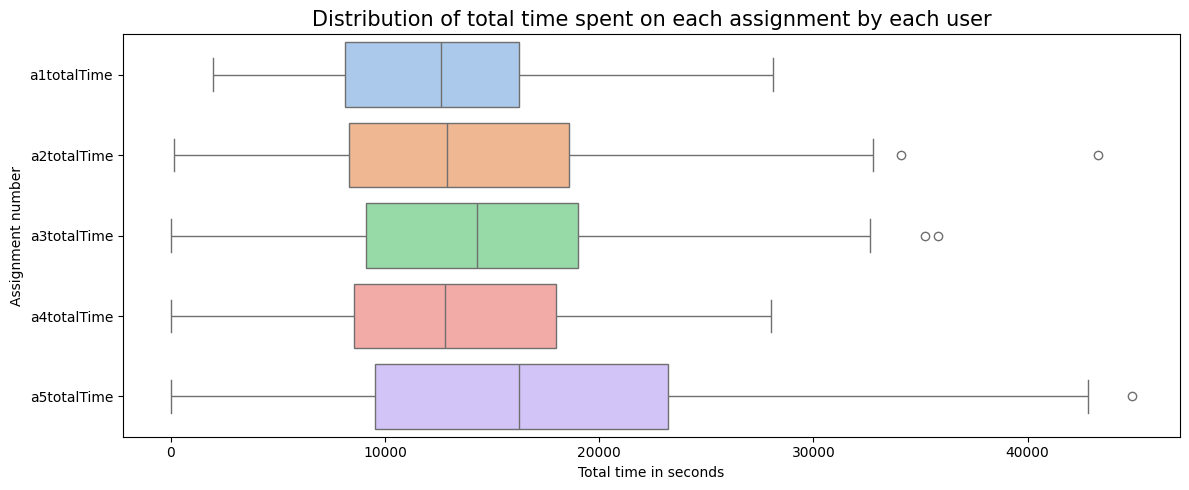

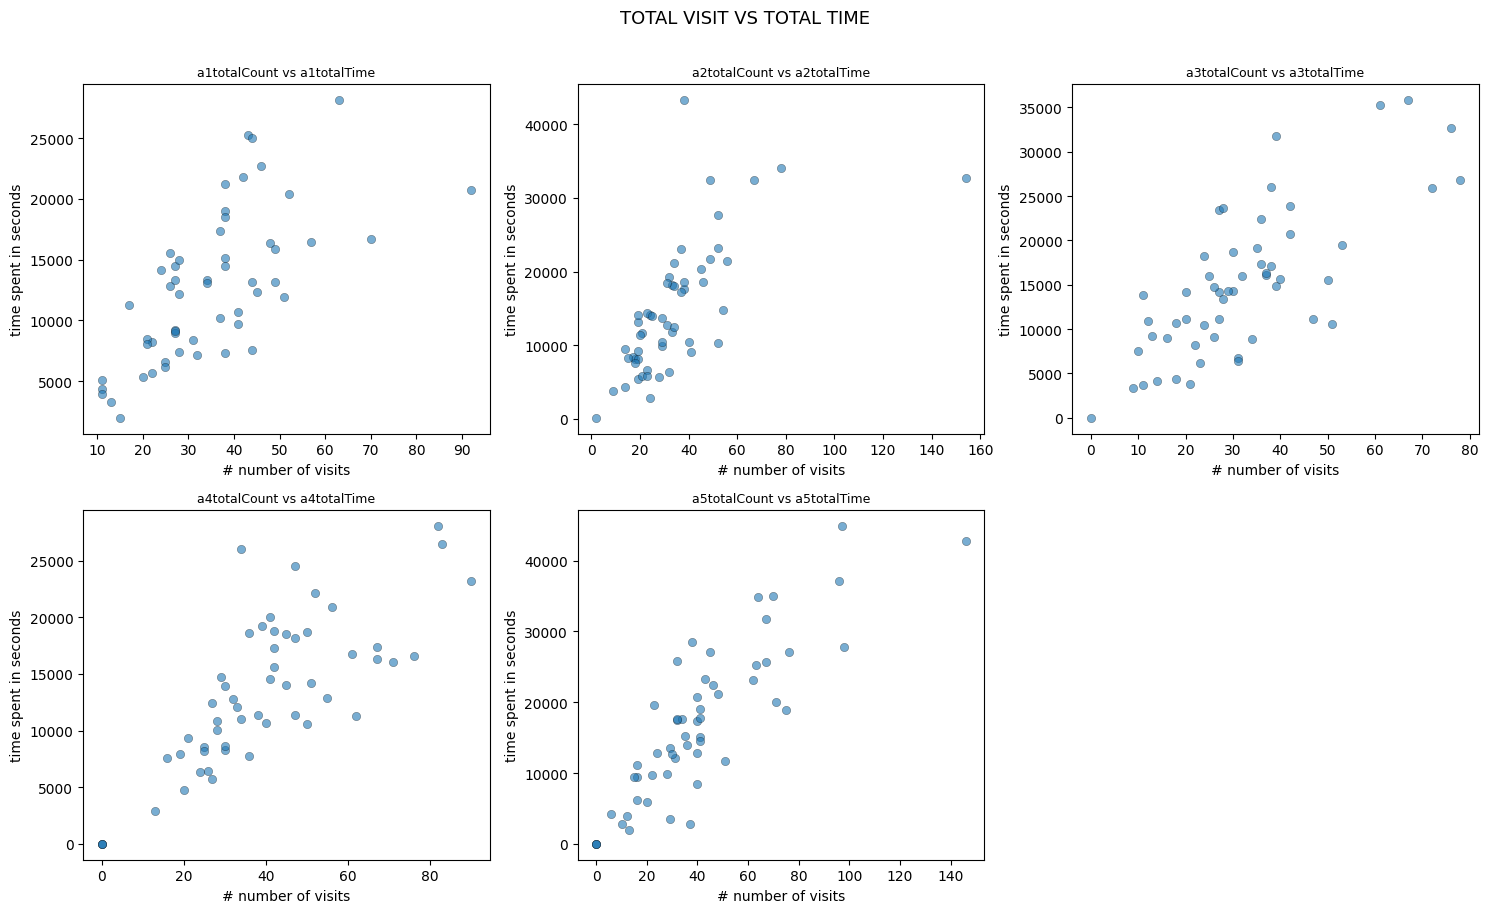

In [62]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=assignemnts.filter(like='totalTime'), orient='h', palette='pastel')
plt.title('Distribution of total time spent on each assignment by each user', fontsize=15)
plt.xlabel('Total time in seconds')
plt.ylabel('Assignment number')
plt.tight_layout()
plt.show()


count_cols = assignemnts.filter(like='totalCount').columns.tolist()
n = len(count_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    time_col = col.replace('totalCount', 'totalTime')
    axes[i].scatter(assignemnts[col], assignemnts[time_col], alpha=0.6, edgecolors='k', linewidths=0.3)
    axes[i].set_title(f"{col} vs {time_col}", fontsize=9)
    axes[i].set_xlabel("# number of visits")
    axes[i].set_ylabel("time spent in seconds")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('TOTAL VISIT VS TOTAL TIME', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Merge with grades and check correlations

Now that we have our first engineered features, let's see if they actually **predict grades**.
We'll merge the feature DataFrame with the grades and compute Pearson correlations.

> 💡 Pearson correlation ranges from −1 (perfect negative) to +1 (perfect positive). 
> A value of 0 means no linear relationship. Correlations around ±0.2–0.4 are already interesting for behavioural data.

In [63]:
grades = pd.merge(grades, assignemnts, on="userID", how='left')

print(f"Grades DataFrame shape: {grades.shape}" )
grades.head()

Grades DataFrame shape: (54, 17)


,userID,A1,A2,A3,A4,A5,FinalScore,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,93.75,68.75,100.00,76.47,82.05,59.97,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,112.50,125.00,100.00,88.24,92.31,77.81,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,100.00,125.00,121.43,94.12,93.59,89.88,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,116.67,125.00,75.00,52.94,57.69,73.30,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,95.83,106.25,82.14,35.29,33.33,56.57,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [64]:
correlation_results = {}

for i in range(1, 6):
    grade_col = f'A{i}'
    time_col = f'a{i}totalTime'

    if grade_col in grades.columns and time_col in grades.columns:
        corr = grades[[grade_col, time_col]].corr().iloc[0, 1]        
        correlation_results[grade_col] = round(corr, 3)

print("let's see if there's a correlatino between grades and total time spent on an assignment: ")

print(correlation_results)

for k, v in correlation_results.items():
    print(f" {k} ~ {k.lower()}totalTime: r = {v}")

let's see if there's a correlatino between grades and total time spent on an assignment: 
{'A1': np.float64(0.351), 'A2': np.float64(0.207), 'A3': np.float64(0.444), 'A4': np.float64(0.551), 'A5': np.float64(0.555)}
 A1 ~ a1totalTime: r = 0.351
 A2 ~ a2totalTime: r = 0.207
 A3 ~ a3totalTime: r = 0.444
 A4 ~ a4totalTime: r = 0.551
 A5 ~ a5totalTime: r = 0.555


These are decent correlations for a behavioural feature.
A2 is the exception — we'd want to investigate the assignment content to understand why.

Let's also look at the **full correlation matrix** across all grade and feature columns to get a wider picture.

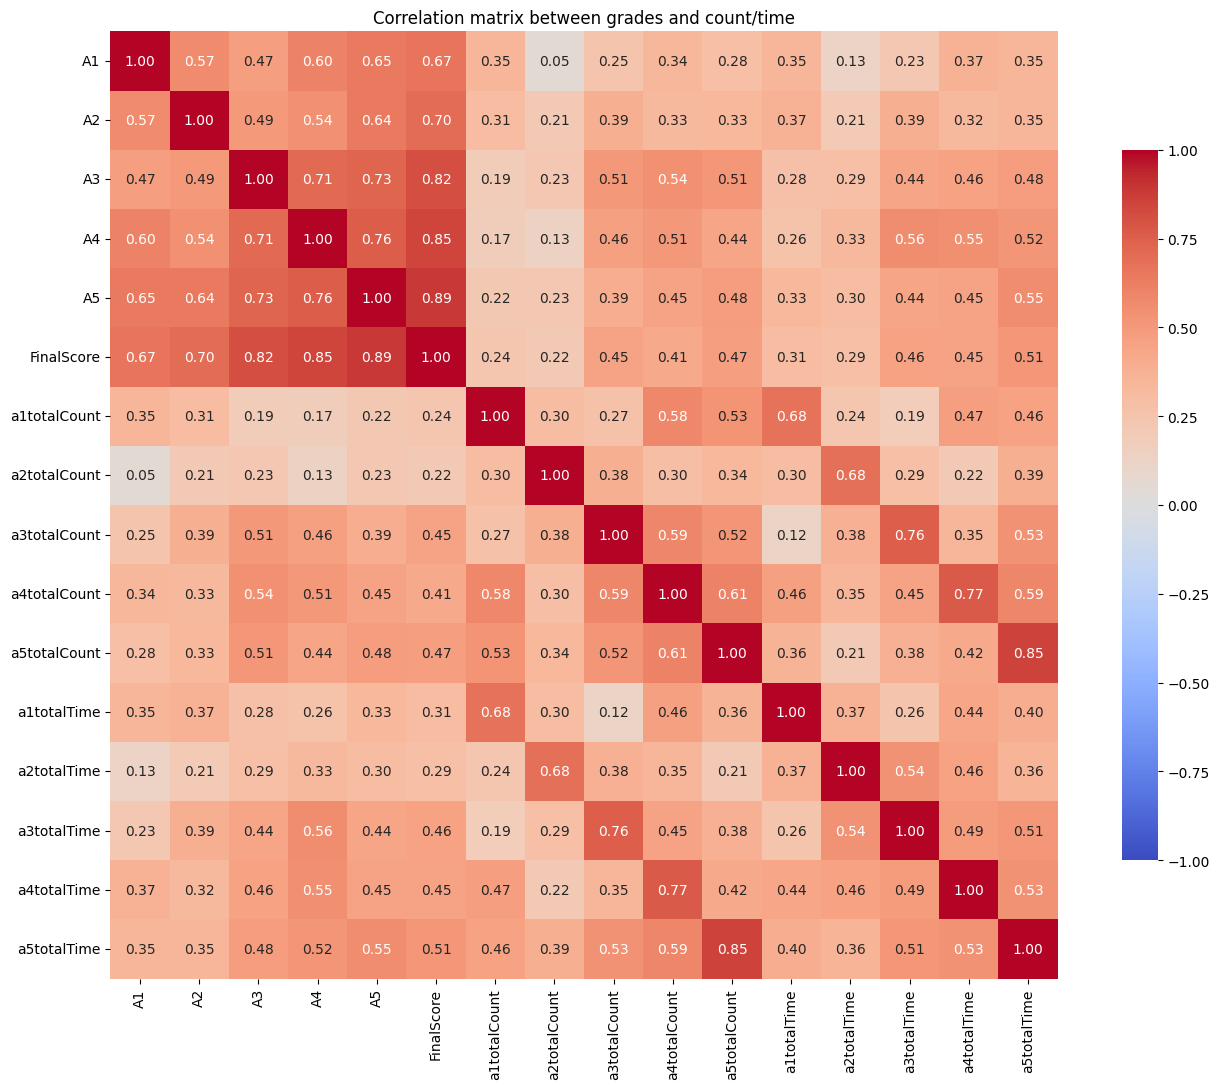

In [65]:
correlation_matrix = grades.drop(columns=['userID']).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    correlation_matrix,
    annot=True, fmt=".2f", cmap='coolwarm',
    square=True, cbar_kws={"shrink": 0.75},
    vmin=-1, vmax=1
)
plt.title("Correlation matrix between grades and count/time")
plt.tight_layout()
plt.show()

---
## Feature Family 2 — Temporal / Day-Based Features

Counts and time tell us *how much* a student engaged. 
But **when** they worked can be equally important:

| Feature | Question answered |
|---|---|
| `firstDay` | How early did they start (days before deadline)? |
| `secondDay` | When did they come back for the second session? |
| `nDays` | Over how many distinct days did they work? |
| `nDaysFinalWeek` | Did they cram everything into the last 7 days? |
| `nDaysAfterDeadline` | Did they access pages after the deadline (late submission risk)? |

> 💡 **Key idea:** A student who starts 14 days before the deadline and works a little each day
> has a very different pattern from one who starts the night before.
> These features give the model a way to capture that difference.

First, we need the **deadline dates** for each assignment.

In [66]:
a1deadline = pd.to_datetime('2026-05-27 23:59:00-07:00')
a2deadline = pd.to_datetime('2026-06-15 23:59:00-07:00')

deadlines = {
    'a1': a1deadline,
    'a2': a2deadline
}

print(deadlines)

for k, v in deadlines.items():
    print(f"{k}: {v.date()}")

{'a1': Timestamp('2026-05-27 23:59:00-0700', tz='UTC-07:00'), 'a2': Timestamp('2026-06-15 23:59:00-0700', tz='UTC-07:00')}
a1: 2026-05-27
a2: 2026-06-15


Now we loop over every (student, assignment) group in the log to compute the temporal features.

The key formula is:
```
days_before_deadline = (deadline.date() - access_date).days
```
A positive number means the student accessed the page **before** the deadline.
A negative number means they accessed it **after** — which might indicate late work or reviewing feedback.

In [67]:
log['start_time'] = pd.to_datetime(log['start_time'], utc=True)

log['date'] = log['start_time'].dt.date

#rows is used to build a temporal variable for each (student, assignment pair)
rows = []

for (user, assignment), group in log.groupby(['userID', 'assignment']):
    if assignment not in deadlines:
        continue

    deadline = deadlines[assignment]

    dates = sorted(set(group['date'])) 

    days_before = [(deadline.date() - d).days for d in dates]

    days_in_last_week = [d for d in dates if 0 <= (deadline.date() - d).days <= 7]

    rows.append({
        'userID':  user,
        'assignment': assignment,

        'firstDay': days_before[0] if len(days_before) >= 1 else None,

        'secondDay': days_before[1] if len(days_before) >= 2 else None,

        'firstSecondGap': (days_before[0] - days_before[1]) if len(days_before) >=2 else None,

        'nDays': len(dates),

        'nDaysFinalWeek': len(days_in_last_week),

        'nDaysBeforeFinalWeek': len([d for d in days_before if d > 7]),

         'nDaysAfterDeadline': len([d for d in days_before if d < 0]),
    }
    )

activity_summary = pd.DataFrame(rows)

print(f"activity dataframe shape: {activity_summary.shape}")

activity_summary.head(10)



activity dataframe shape: (108, 9)


,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,7,4,3,7,6,0,1
1,100001,a2,18,12,6,11,6,4,1
2,100002,a1,16,9,7,9,6,2,1
3,100002,a2,19,18,1,14,5,6,3
4,100003,a1,12,6,6,7,6,1,0
5,100003,a2,18,14,4,6,2,3,1
6,100004,a1,6,1,5,5,3,0,2
7,100004,a2,18,2,16,4,2,1,1
8,100005,a1,6,5,1,6,5,0,1
9,100005,a2,17,15,2,10,4,5,1


### Reshaping the data: wide vs. long format

Right now `grades` is in **wide format** (one row per student, one column per assignment per feature).
`activity_summary` is in **long format** (one row per student–assignment pair).

To cleanly merge temporal features with grades, we'll convert everything to long format first.

> 💡 `pd.melt()` is the pandas function for converting from wide to long.
> It "unpivots" selected columns into rows.

In [68]:
# turn wide into long
grades_long = pd.melt(
    grades[['userID', 'A1', 'A2']],
    id_vars='userID',
    value_vars=['A1', 'A2'],
    var_name='assignment_label',
    value_name='grade'
)

# change to lowercase to match activity_summary
grades_long['assignment'] = grades_long['assignment_label'].str.lower()

# drop unused column
grades_long = grades_long.drop(columns='assignment_label')

# check shape and preview
print(f"grades_long shape: {grades_long.shape}")
grades_long.head(10)

grades_long shape: (108, 3)


,userID,grade,assignment
0,100001,93.75,a1
1,100002,112.50,a1
2,100003,100.00,a1
3,100004,116.67,a1
4,100005,95.83,a1
5,100006,70.83,a1
6,100007,106.92,a1
7,100008,77.08,a1
8,100009,70.83,a1
9,100010,108.33,a1


Now merge the temporal features into our long-format dataset.

In [69]:
# merge temporal features with grades
temporal_features = pd.merge(grades_long, activity_summary, on=['userID', 'assignment'], how='left')

# check shape and preview
print(f"temporal_features shape: {temporal_features.shape}")
print("Columns:", temporal_features.columns.tolist())
temporal_features.head(10)

temporal_features shape: (108, 10)
Columns: ['userID', 'grade', 'assignment', 'firstDay', 'secondDay', 'firstSecondGap', 'nDays', 'nDaysFinalWeek', 'nDaysBeforeFinalWeek', 'nDaysAfterDeadline']


,userID,grade,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,93.75,a1,7,4,3,7,6,0,1
1,100002,112.50,a1,16,9,7,9,6,2,1
2,100003,100.00,a1,12,6,6,7,6,1,0
3,100004,116.67,a1,6,1,5,5,3,0,2
4,100005,95.83,a1,6,5,1,6,5,0,1
5,100006,70.83,a1,4,1,3,4,2,0,2
6,100007,106.92,a1,6,2,4,4,4,0,0
7,100008,77.08,a1,6,5,1,6,5,0,1
8,100009,70.83,a1,6,5,1,10,6,0,4
9,100010,108.33,a1,8,6,2,7,4,1,2


## Correlation matrix: all features vs. grades

Let's see how well our temporal features correlate with each assignment grade.

Because our data is now in long format, we first need to pivot it back to wide format
so that each column corresponds to one (feature, assignment) combination —
that's what we need for a heatmap.

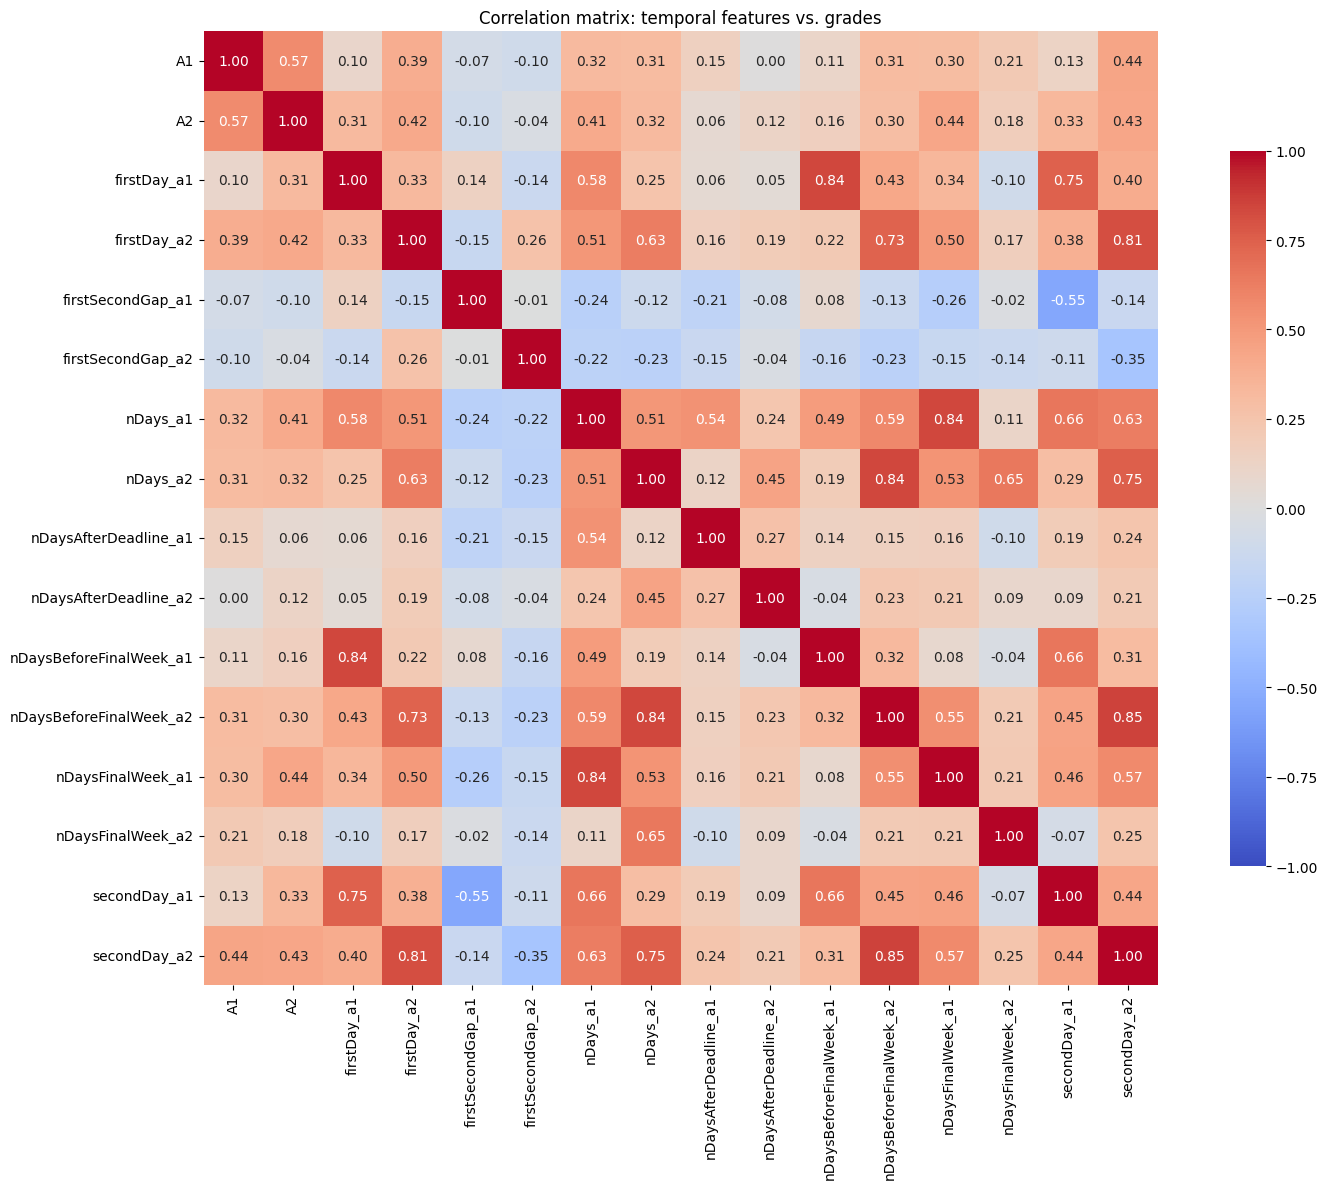

In [70]:
# list of temporal features
temporal_cols = ['firstDay', 'secondDay', 'firstSecondGap', 'nDays', 'nDaysFinalWeek','nDaysBeforeFinalWeek', 'nDaysAfterDeadline']

# pivot back to wide format
wide_temporal = temporal_features.pivot_table(
    index='userID',
    columns='assignment',
    values=temporal_cols
)

# flatten column names, e.g. firstDay_a1
wide_temporal.columns = [f"{feat}_{asgn}" for feat, asgn in wide_temporal.columns]
wide_temporal = wide_temporal.reset_index()

# merge back with grades
grades_for_corr = grades[['userID', 'A1', 'A2']].merge(wide_temporal, on='userID', how='left')

# compute correlations
corr_matrix = grades_for_corr.drop(columns='userID').corr()

# plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap='coolwarm',
    square=True, cbar_kws={"shrink": 0.75},
    vmin=-1, vmax=1
)
plt.title("Correlation matrix: temporal features vs. grades")
plt.tight_layout()
plt.show()

Some features are **redundant** (collinear): `firstSecondGap` can always be derived from `firstDay` and `secondDay`.
Keeping redundant features in a regression model can cause instability.
Let's drop them.

In [71]:
# find redundant columns
redundant_cols = [col for col in wide_temporal.columns if 'firstSecondGap' in col or 'secondDay' in col]

print("Dropping redundant columns:", redundant_cols)

# drop them
wide_temporal_clean = wide_temporal.drop(columns=redundant_cols)

# check what's left
print(f"Shape after dropping: {wide_temporal_clean.shape}")
print("Remaining columns:", wide_temporal_clean.columns.tolist())

Dropping redundant columns: ['firstSecondGap_a1', 'firstSecondGap_a2', 'secondDay_a1', 'secondDay_a2']
Shape after dropping: (54, 11)
Remaining columns: ['userID', 'firstDay_a1', 'firstDay_a2', 'nDays_a1', 'nDays_a2', 'nDaysAfterDeadline_a1', 'nDaysAfterDeadline_a2', 'nDaysBeforeFinalWeek_a1', 'nDaysBeforeFinalWeek_a2', 'nDaysFinalWeek_a1', 'nDaysFinalWeek_a2']


---
## Feature Family 3 — Ratios

Counts and totals answer *how much*. Ratios answer *what proportion*.

Consider:
- Student A spent 2 hours on the assignment and 1 hour on the detail spec page → **50% detail ratio**
- Student B spent 10 hours on the assignment and 1 hour on the detail spec page → **10% detail ratio**

Both spent the same absolute time on the detail page, but Student B spread their effort much more broadly.
A ratio feature captures this relative behaviour.

We will compute: **`detailRatio`** = (time spent on detail pages) / (total time on all assignment pages)

> 💡 A Canvas assignment typically has several pages. The **detail** page contains the full specification.
> Students who spend more relative time on the spec may be doing more careful reading.

Let's check whether `detailRatio` correlates with grades.

---
## Putting it all together — Linear Regression

Now that we have three families of features, let's fit a simple **multiple linear regression** model
to predict each assignment grade.

This is not the main focus of today's lecture, but it gives us a concrete way to evaluate
whether our feature engineering paid off:
- **R²** — what percentage of grade variance do our features explain?
- **RMSE** — on average, how many grade points is our prediction off by?
- **Coefficients** — which features are most influential?

> ⚠️ **Important:** We are fitting on the full dataset (no train/test split) just to get a feel for the features.
> In a proper study you would use cross-validation (see the `LeaveOneOut` import below).

Let's run a separate model for each assignment.

Note: `totalTime` is in **seconds**, which is a very large number compared to a grade (0–100).
The coefficient printed will look like 0.000, not because time has no effect,
but because one extra *second* barely moves the grade.
We'll convert to hours to make the coefficient interpretable.

### Interpreting the model

**How to read the coefficients:**
- A coefficient of `+2.5` on `firstDay` means: *for every extra day earlier a student started, the model predicts 2.5 more grade points* (all else being equal).
- A coefficient of `−5.6` on `nDaysAfterDeadline` means: *each day a student accessed pages after the deadline is associated with −5.6 grade points* — possibly indicating late or incomplete submissions.

**Why R² is modest (~0.25):**
> This model has no information about the student's background or programming skill.
> A strong programmer might spend very little time on Canvas yet score 95.
> A struggling student might spend many hours yet score 40.
> Our behavioural features alone can explain about 25% of the variance — which is actually meaningful given what we're working with!

---
## Summary: What we did today

| Step | Action | Pandas / sklearn tool |
|---|---|---|
| 1 | Counted page views per student per assignment | `groupby().size().unstack()` |
| 2 | Summed time spent per student per assignment | `groupby()[col].sum().unstack()` |
| 3 | Computed temporal features (days before deadline) | Manual loop + `pd.DataFrame` |
| 4 | Reshaped data from wide to long | `pd.melt()` + `pd.merge()` |
| 5 | Computed ratio feature (detail page proportion) | Column arithmetic |
| 6 | Evaluated all features with correlation heatmap | `.corr()` + `sns.heatmap()` |
| 7 | Dropped redundant/collinear features | `df.drop(columns=[...])` |
| 8 | Fit linear regression to assess predictive power | `sklearn.LinearRegression` |

**Key takeaways:**
- Feature engineering turns raw events into model-ready inputs using domain knowledge.
- Always **visualise and check correlations** before using features in a model.
- **Redundant features** (those that can be derived from others) should be removed to avoid collinearity.
- **Scale matters**: a feature in seconds and a feature in counts are on very different scales — consider normalising or converting units before interpreting coefficients.